# Phys 610 Midterm
## Problems 6-8
### Sean Ericson

In [11]:
# Imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

mpl.rcParams['figure.dpi'] = 300

In [12]:
def effective_potential(r, M, b, l):
    tmp = r*r + b*b
    return 0.5*((1 - 2*M/np.sqrt(tmp))*(1 + l*l/tmp) - 1)

def r_prime(r, M, b, l, E):
    return (r*r + b*b) * np.sqrt(2 * (E - effective_potential(r, M, b, l))) / l

def f(t, r, M, b, l, E):
    return r_prime(r, M, b, l, E)

In [13]:
r0 = 20
M = 1
b = 0
l = 4.3
E = -0.0001
t_min = 0
t_max = 1

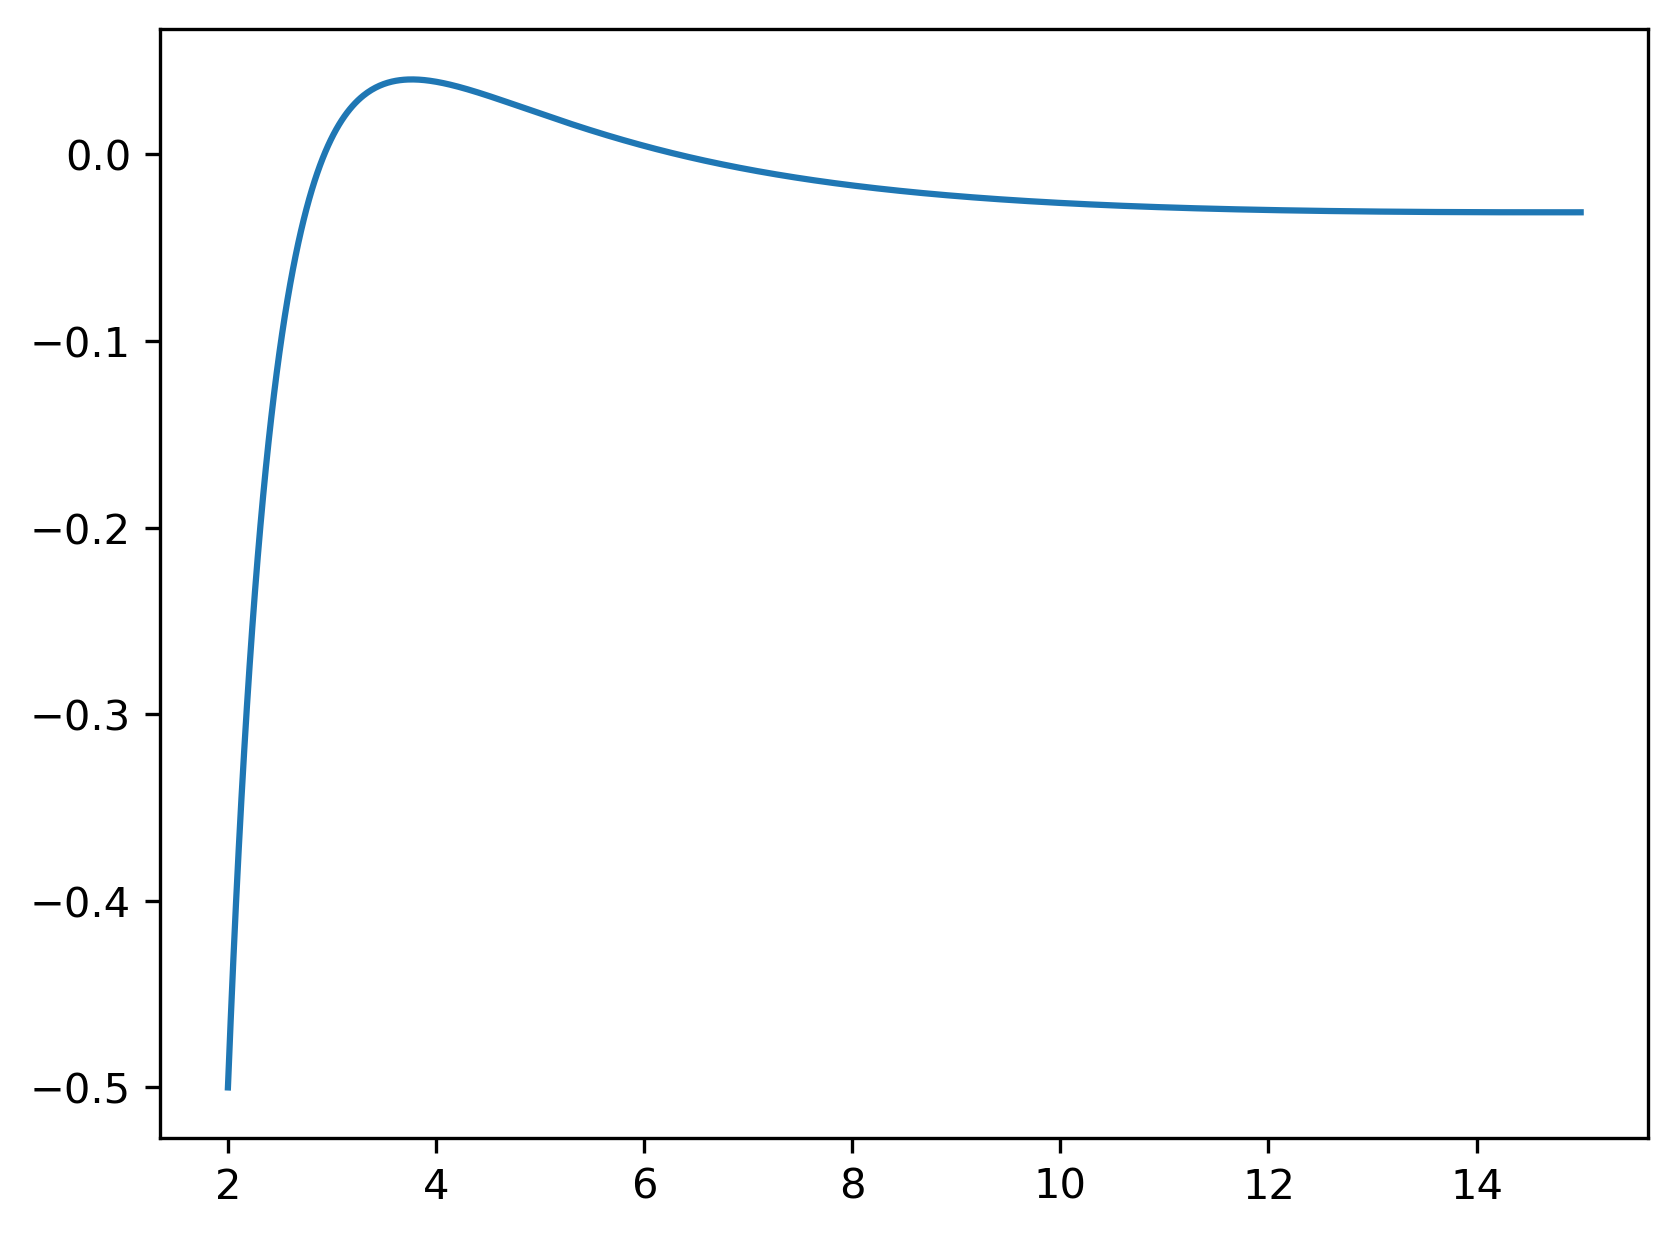

In [14]:
rs = np.linspace(2*M, 15, 1000)
Vs = [effective_potential(r, M, b, l) for r in rs]
plt.plot(rs, Vs)

In [15]:
result = solve_ivp(f, (t_min, t_max), [r0], args=(M,b,l,E), max_step=0.01)
print(result.message)

The solver successfully reached the end of the integration interval.


[Text(0.0, 0, ''),
 Text(0.7853981633974483, 0, ''),
 Text(1.5707963267948966, 0, ''),
 Text(2.356194490192345, 0, ''),
 Text(3.141592653589793, 0, ''),
 Text(3.9269908169872414, 0, ''),
 Text(4.71238898038469, 0, ''),
 Text(5.497787143782138, 0, '')]

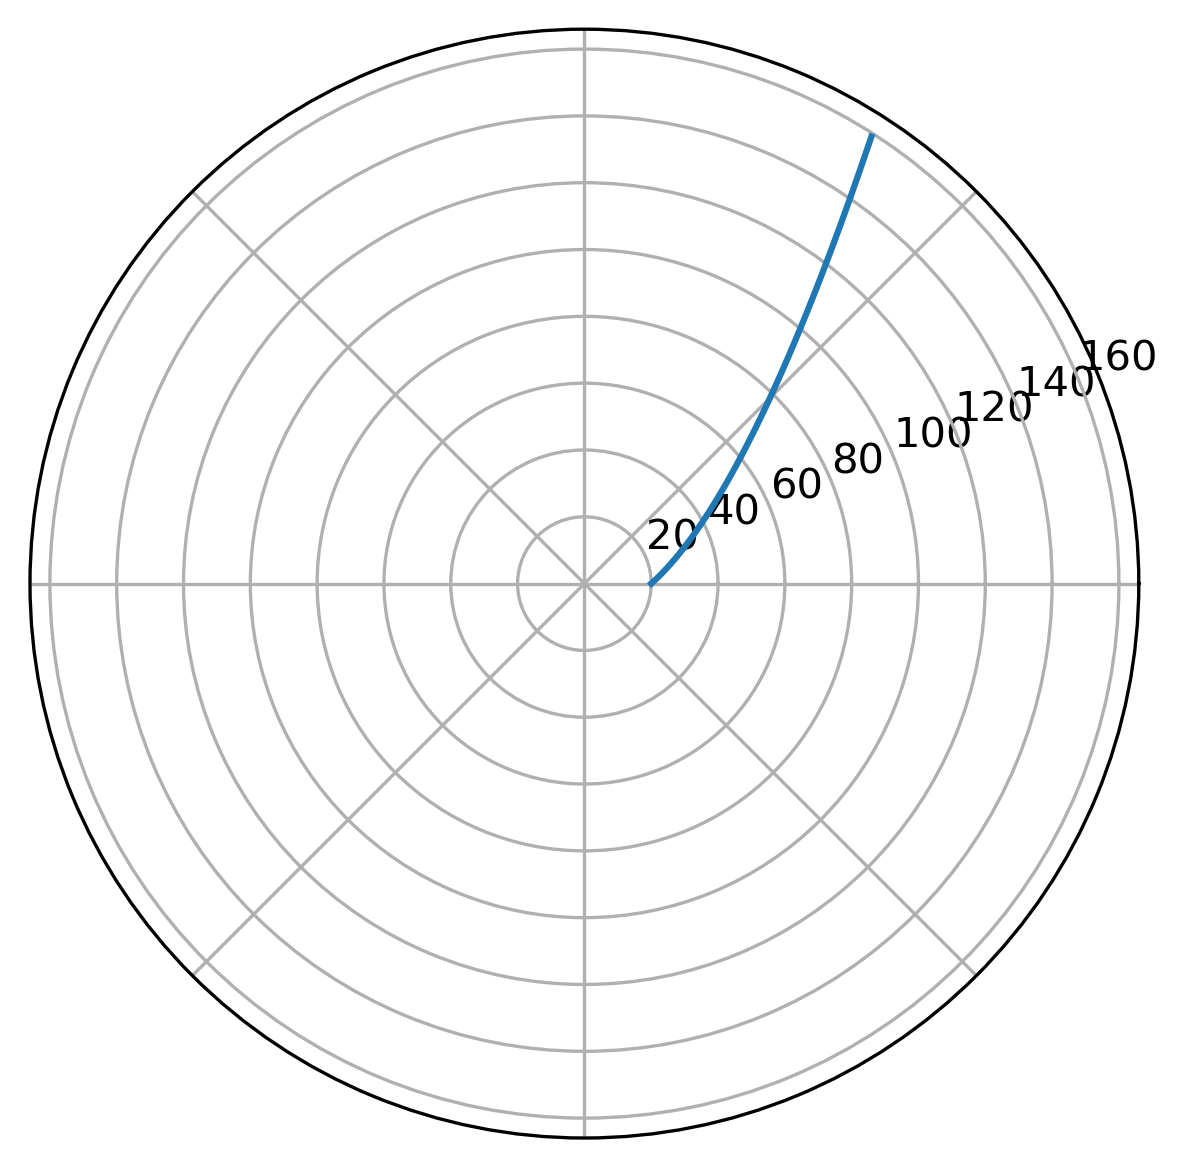

In [16]:
#Make plt figure
fig = plt.figure()

#Make sub-plot with attribute "polar"
ax = fig.add_subplot(polar=True)

#Plot function
ax.plot(result.t, result.y[0])
ax.set_xticklabels([])

In [17]:
def f1(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    return -2 * M * r * r_dot * t_dot / (tmp1 * np.sqrt(tmp1 - 2*M))

def f2(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    tmp2 = np.sqrt(tmp1 - 2*M)
    return r * (tmp2*tmp2*(np.power(tmp1, 3/2)*(np.power(np.sin(theta), 2)*phi_dot*phi_dot + theta_dot*theta_dot) - M*t_dot*t_dot) + M*tmp1*r_dot*r_dot) / (tmp1*tmp1*tmp2)

def f3(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    return np.sin(theta)*np.cos(theta)*phi_dot*phi_dot - 2*r*r_dot*theta_dot/tmp1

def f4(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    return 2*phi_dot*(theta_dot/np.tan(theta) + r*r_dot/tmp1)

def f(t, y, M, b):
    return (y[1], f1(y, M, b), y[3], f2(y, M, b), y[5], f3(y, M, b), y[7], f4(y, M, b))